#Imports


In [ ]:
# Visualisation Imports
import matplotlib.pyplot as plt        # For plotting and visualisations
import seaborn as sns                  # For statistical visualisations


# Preprocessing Imports
import pandas as pd                   #For data manipulation & analysis
import numpy as np                    #For numerical operations
from sklearn import preprocessing # Import the preprocessing module from scikit-learn for data transformation utilities
from collections import Counter # Import Counter to count occurrences of labels/classes in the dataset
from sklearn.preprocessing import StandardScaler # Import StandardScaler to normalize the feature values (mean = 0, std = 1)
from imblearn.over_sampling import SMOTE   #to balance our data using smote
from sklearn.model_selection import train_test_split # to split the data into test and train sets
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
)  #For performance metrics
from sklearn.preprocessing import LabelEncoder  # For label encoding


In [ ]:
!pip install imbalanced-learn

In [ ]:
# Modelling Imports
from sklearn.ensemble import RandomForestClassifier # Import the RandomForestClassifier model from scikit-learn
from sklearn.model_selection import GridSearchCV # Import GridSearchCV for hyperparameter tuning using cross-validation
import shap                            # For SHAP value analysis

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=c18b34cfa84af4c8bed1221dc02f8a3e1dff0552327ecc7bbfd705fe522bd342
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
from lime import lime_tabular

In [ ]:
from lime.lime_tabular import LimeTabularExplainer


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

#Dataset

In [ ]:
# Load the dataset into a DataFrame
df = pd.read_csv("loans_data.csv")

In [ ]:
# Display the first 5 rows of the dataset to understand its structure
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
# Check the shape of the dataset
df.shape

(614, 13)

In [ ]:
#Check the data types
print(df.dtypes)

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object


In [ ]:
# in the Dependents column, Replace '3+' with 3 and convert to numeric
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce')

In [ ]:
print(df.dtypes)

Loan_ID               object
Gender                object
Married               object
Dependents           float64
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object


#Visualisations


In [ ]:
# Define the mapping for Credit_History
credit_history_map = {
    0.0: 'Bad Credit History',
    1.0: 'Good Credit History'
}

# Apply the mapping to the 'Credit_History' column
df['Credit_History'] = df['Credit_History'].map(credit_history_map)

In [ ]:
# Define the mapping for Loan_Status
loan_status_map = {
    'Y': 'Yes',
    'N': 'No'
}

# Apply the mapping to the 'Loan_Status' column
df['Loan_Status'] = df['Loan_Status'].map(loan_status_map)

In [ ]:
# Display the first 5 rows of the dataset
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,Good Credit History,Urban,Yes
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,Good Credit History,Rural,No
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,Good Credit History,Urban,Yes
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,Good Credit History,Urban,Yes
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,Good Credit History,Urban,Yes


Loan Status Distribution

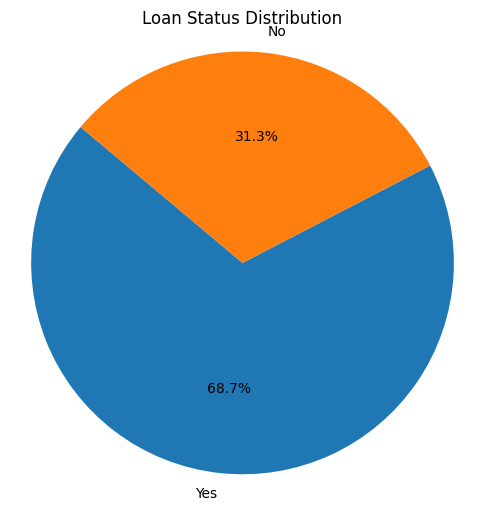

In [ ]:
# Count the values in the 'loan_status' column
loan_status_counts = df['Loan_Status'].value_counts()

# Plot the pie chart
plt.figure(figsize=(6, 6))
plt.pie(loan_status_counts, labels=loan_status_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Loan Status Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

#autopct='%1.1f%%' shows percentages on the chart.
#startangle=140 rotates the start of the pie chart for aesthetics.

Histograms

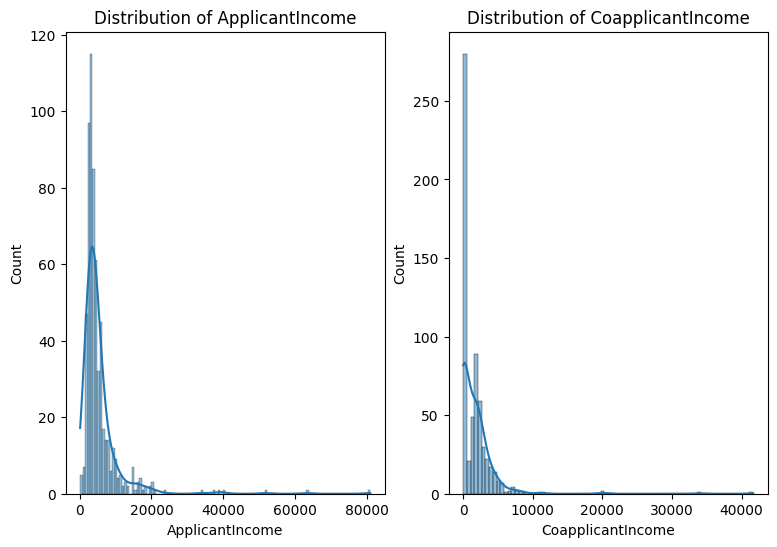

In [ ]:
# Histograms for Applicant and Coapplicant Income
plt.figure(figsize=(14, 6))
for i, column in enumerate(['ApplicantIncome', 'CoapplicantIncome']):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
plt.show()

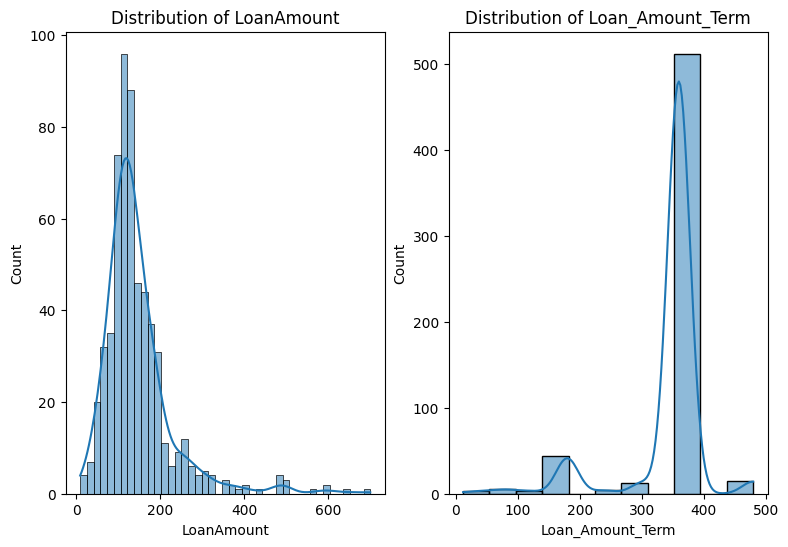

In [ ]:
# Histograms for Loan Amount and Loan term
plt.figure(figsize=(14, 6))
for i, column in enumerate(['LoanAmount', 'Loan_Amount_Term']):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
plt.show()

Grouped Bar Charts

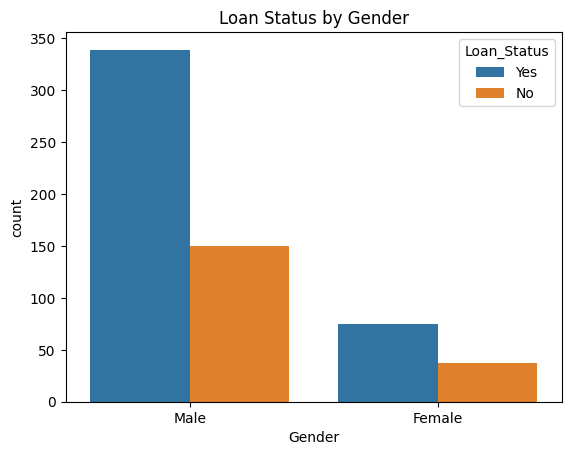

In [ ]:
# Loan Status and Gender
sns.countplot(data=df, x='Gender', hue='Loan_Status')
plt.title("Loan Status by Gender")
plt.show()

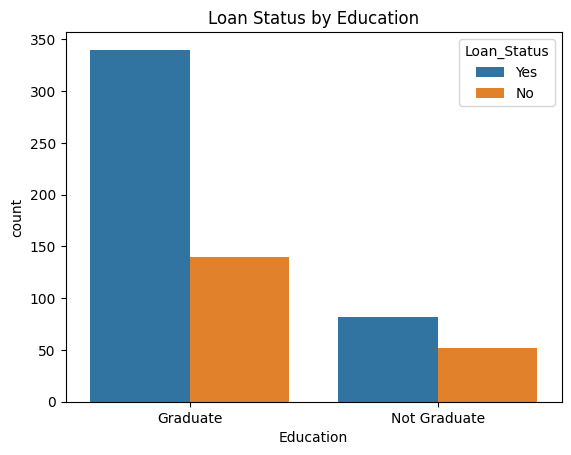

In [ ]:
# Loan Status and Education
sns.countplot(data=df, x='Education', hue='Loan_Status')
plt.title("Loan Status by Education")
plt.show()


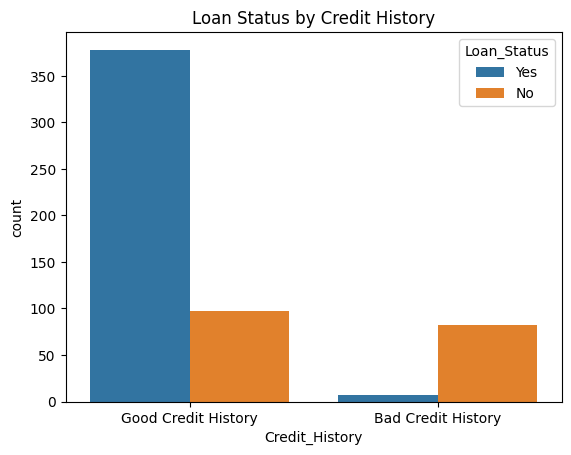

In [ ]:
# Loan Status and Credit History
sns.countplot(data=df, x='Credit_History', hue='Loan_Status')
plt.title("Loan Status by Credit History")
plt.show()

# Correlation Analysis

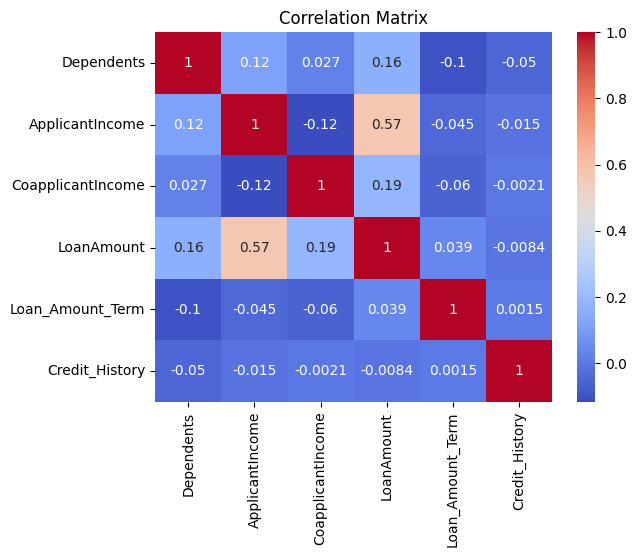

In [ ]:
# Create the correlation matrix for all numeric features in the df
correlation_matrix = df.corr(numeric_only=True)

# Create a heatmap using seaborn to visualise the correlation matrix
# 'annot=True' displays the correlation coefficients inside the squares
# 'cmap="coolwarm"' sets the color scheme for better visual distinction of positive and negative correlations
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
# Add a title to the heatmap
plt.title("Correlation Matrix")

# Display the heatmap plot
plt.show()

#Descriptive Statistics

In [ ]:
# Display summary statistics for numeric columns
df.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
count,599.000000,614.000000,614.000000,592.000000,600.00000
mean,0.762938,5403.459283,1621.245798,146.412162,342.00000
std,1.015216,6109.041673,2926.248369,85.587325,65.12041
min,0.000000,150.000000,0.000000,9.000000,12.00000
25%,0.000000,2877.500000,0.000000,100.000000,360.00000
50%,0.000000,3812.500000,1188.500000,128.000000,360.00000
75%,2.000000,5795.000000,2297.250000,168.000000,360.00000
max,3.000000,81000.000000,41667.000000,700.000000,480.00000


In [ ]:
# Basic statistics for categorical columns
df.describe(include=['object'])

,Loan_ID,Gender,Married,Education,Self_Employed,Credit_History,Property_Area,Loan_Status
count,614,601,611,614,582,564,614,614
unique,614,2,2,2,2,2,3,2
top,LP002990,Male,Yes,Graduate,No,Good Credit History,Semiurban,Yes
freq,1,489,398,480,500,475,233,422


# Data Preprocessing

In [ ]:
df = pd.read_csv("loans_data.csv")

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Dropping Noisy Attributes

In [ ]:
# Drop 'Loan_ID' as it is a unique identifier and not useful for prediction
df = df.drop('Loan_ID', axis=1)

In [ ]:
# in the Dependents column, Replace '3+' with 3 and convert to numeric
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce')

In [ ]:
# Display the first 5 rows of the dataset
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Handling Missing Values

In [ ]:
# Check for missing values in the dataset
df.isnull().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [ ]:
# Using mode imputation for categorical features
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [ ]:
# Using median imputation for numeric features
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

In [ ]:
df.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


Label Encoding

In [ ]:
# Encode categorical variables using Label Encoding

# Initiate the encoder
le = LabelEncoder()

# Apply label encoding to the 'Gender' column
df['Gender'] = le.fit_transform(df['Gender'])

# Apply label encoding to the 'Married' column
df['Married'] = le.fit_transform(df['Married'])

# Apply label encoding to the 'Education' column
df['Education'] = le.fit_transform(df['Education'])

# Apply label encoding to the 'Self_Employed' column
df['Self_Employed'] = le.fit_transform(df['Self_Employed'])

# Apply label encoding to the 'Property_Area' column
df['Property_Area'] = le.fit_transform(df['Property_Area'])

# Apply label encoding to the target variable 'Loan_Status'
df['Loan_Status'] = le.fit_transform(df['Loan_Status'])

In [ ]:
# Display the first 5 rows of the dataset
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0.0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1.0,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0.0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0.0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0.0,0,0,6000,0.0,141.0,360.0,1.0,2,1


Balancing the classes and splitting the train and test sets

In [ ]:
loan_status_count = df['Loan_Status'].value_counts()
print(loan_status_count)

Loan_Status
1    422
0    192
Name: count, dtype: int64


In [ ]:
X = df.iloc[:, :-1].values    # predictor attributes
y = df.iloc[:,-1].values     # target attribute

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
oversample = SMOTE()
X_train_sm, y_train_sm = oversample.fit_resample(X_train, y_train) # using smote

In [ ]:
# Check the value counts
count = Counter(y_train_sm)
count

Counter({np.int64(0): 342, np.int64(1): 342})

#Classification on the Loan_Status feature

# **1. Random Forest Model**

Feature Importance

In [ ]:
# Fitting the RF model to the df before balancing
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

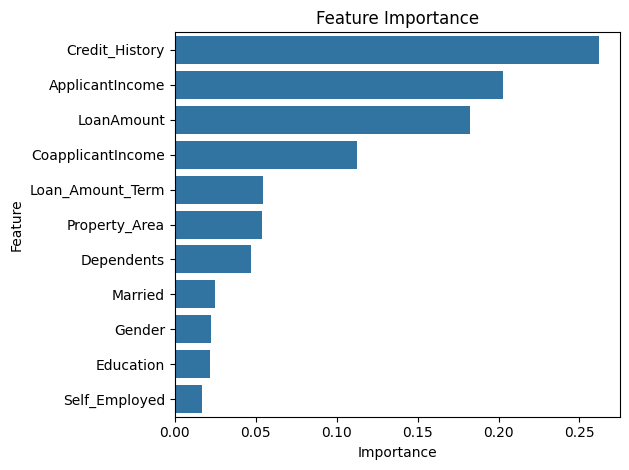

In [ ]:
importances = model.feature_importances_

# Use original column names
feature_names = df.drop('Loan_Status', axis=1).columns

# Create and sort DataFrame
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

# **Random Forest with all features**



In [ ]:
# Fitting the RF Model to the balanced data
model = RandomForestClassifier()
model.fit(X_train_sm, y_train_sm)

RandomForestClassifier()

In [ ]:
from sklearn.model_selection import cross_val_predict

# Generate cross-validated predictions
y_pred_cv = cross_val_predict(model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC
y_proba_cv = cross_val_predict(model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# === Map class labels 0 -> 'No', 1 -> 'Yes' ===
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named = pd.Series(y_pred_cv).map(label_map)

# Confusion matrix
cm = confusion_matrix(y_true_named, y_pred_named)
print("Confusion Matrix:\n", cm)

# Accuracy
acc = accuracy_score(y_true_named, y_pred_named)
print("Accuracy:", acc)

# Precision
precision = precision_score(y_true_named, y_pred_named, pos_label='Yes')
print("Precision:", precision)

# Recall
recall = recall_score(y_true_named, y_pred_named, pos_label='Yes')
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_true_named, y_pred_named, pos_label='Yes')
print("F1 Score:", f1)

# AUC Score
auc = roc_auc_score(y_train_sm, y_proba_cv)
print("AUC Score:", auc)

# Full Classification Report
print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named))

Confusion Matrix:
 [[277  65]
 [ 28 314]]
Accuracy: 0.8640350877192983
Precision: 0.8284960422163589
Recall: 0.9181286549707602
F1 Score: 0.871012482662968
AUC Score: 0.9121652816251155

Classification Report:
               precision    recall  f1-score   support

          No       0.91      0.81      0.86       342
         Yes       0.83      0.92      0.87       342

    accuracy                           0.86       684
   macro avg       0.87      0.86      0.86       684
weighted avg       0.87      0.86      0.86       684



# **Random Forest after feature selection**

In [ ]:
# Before running this cell, drop noisy attributes, handle missing values, encode categorical features
# Drop low-importance features and retrain the model to compare performance
low_importance_features = ['Self_Employed', 'Gender', 'Education']
df_reduced = df.drop(columns=low_importance_features)

In [ ]:
df_reduced.head()

,Married,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,0.0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1.0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,0.0,3000,0.0,66.0,360.0,1.0,2,1
3,1,0.0,2583,2358.0,120.0,360.0,1.0,2,1
4,0,0.0,6000,0.0,141.0,360.0,1.0,2,1


In [ ]:
loan_status_count = df_reduced['Loan_Status'].value_counts()
print(loan_status_count)

Loan_Status
1    422
0    192
Name: count, dtype: int64


In [ ]:
X = df_reduced.iloc[:, :-1].values    # predictor attributes
y = df_reduced.iloc[:,-1].values     # target attribute

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
oversample = SMOTE()
X_train_sm, y_train_sm = oversample.fit_resample(X_train, y_train) # using smote

In [ ]:
# Check the value counts
count = Counter(y_train_sm)
count

Counter({np.int64(0): 342, np.int64(1): 342})

In [ ]:
# Fitting the RF Model to the balanced and scaled data after feature selection
model = RandomForestClassifier()
model.fit(X_train_sm, y_train_sm)

RandomForestClassifier()

In [ ]:
# Generate cross-validated predictions
y_pred_cv = cross_val_predict(model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC
y_proba_cv = cross_val_predict(model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# === Map class labels 0 -> 'No', 1 -> 'Yes' ===
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named = pd.Series(y_pred_cv).map(label_map)

# Confusion matrix
cm = confusion_matrix(y_true_named, y_pred_named)
print("Confusion Matrix:\n", cm)

# Accuracy
acc = accuracy_score(y_true_named, y_pred_named)
print("Accuracy:", acc)

# Precision
precision = precision_score(y_true_named, y_pred_named, pos_label='Yes')
print("Precision:", precision)

# Recall
recall = recall_score(y_true_named, y_pred_named, pos_label='Yes')
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_true_named, y_pred_named, pos_label='Yes')
print("F1 Score:", f1)

# AUC Score
auc = roc_auc_score(y_train_sm, y_proba_cv)
print("AUC Score:", auc)

# Full Classification Report
print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named))

Confusion Matrix:
 [[272  70]
 [ 27 315]]
Accuracy: 0.8581871345029239
Precision: 0.8181818181818182
Recall: 0.9210526315789473
F1 Score: 0.8665749656121046
AUC Score: 0.9005206730275983

Classification Report:
               precision    recall  f1-score   support

          No       0.91      0.80      0.85       342
         Yes       0.82      0.92      0.87       342

    accuracy                           0.86       684
   macro avg       0.86      0.86      0.86       684
weighted avg       0.86      0.86      0.86       684



# **Hyperparameter Tuning for RF Model**

In [ ]:
# Defining the parameter grid
param_grid = {
    'max_depth': [5, 10, 15, 20, None],  # Varying depth levels for different levels of complexity
    'n_estimators': [50, 100, 150],     # Number of trees in the forest
    'min_samples_split': [2, 10, 20],    # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],       # Minimum samples required at a leaf node
    'max_features': ['sqrt', 'log2'],    # Max number of features considered for splitting
    'bootstrap': [True, False]           # Whether bootstrap samples are used when building trees
}

# Creating the model
rf = RandomForestClassifier(random_state=42)

# Set up grid search for hyperparameter tuning
grid_search = GridSearchCV(
    estimator=rf,            # The base model: RandomForestClassifier
    param_grid=param_grid,   # Dictionary of hyperparameter(s) to test
    cv=5,                    # 5-fold cross-validation to evaluate each setting
    scoring='f1',            # Use f1 score to evaluate model performance
    n_jobs=-1,               # Use all available CPU cores for faster computation
    verbose=1                # Show progress of the grid search in the console
)

# Fitting the grid search to the data
grid_search.fit(X_train_sm, y_train_sm)

# Getting the best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)


Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Best Parameters: {'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 150}
Best F1 Score: 0.8881212692927652


In [ ]:
# Training the final model with best parameters

final_model = RandomForestClassifier(
    bootstrap=False,          # No bootstrapping
    max_depth=10,             # Max depth of the trees
    max_features='sqrt',      # Max features considered for splitting
    min_samples_leaf=4,       # Minimum samples at leaf nodes
    min_samples_split=2,      # Minimum samples to split an internal node
    n_estimators=150,         # Number of trees in the forest
    random_state=42           # Ensuring reproducibility
)

# Fit the model to the balanced and scaled training data
final_model.fit(X_train_sm, y_train_sm)

RandomForestClassifier(bootstrap=False, max_depth=10, min_samples_leaf=4,
                       n_estimators=150, random_state=42)

In [ ]:
# Generate cross-validated predictions
y_pred_cv = cross_val_predict(final_model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC
y_proba_cv = cross_val_predict(final_model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# === Map class labels 0 -> 'No', 1 -> 'Yes' ===
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named = pd.Series(y_pred_cv).map(label_map)

# Confusion matrix
cm = confusion_matrix(y_true_named, y_pred_named)
print("Confusion Matrix:\n", cm)

# Accuracy
acc = accuracy_score(y_true_named, y_pred_named)
print("Accuracy:", acc)

# Precision
precision = precision_score(y_true_named, y_pred_named, pos_label='Yes')
print("Precision:", precision)

# Recall
recall = recall_score(y_true_named, y_pred_named, pos_label='Yes')
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_true_named, y_pred_named, pos_label='Yes')
print("F1 Score:", f1)

# AUC Score
auc = roc_auc_score(y_train_sm, y_proba_cv)
print("AUC Score:", auc)

# Full Classification Report
print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named))

Confusion Matrix:
 [[262  80]
 [ 16 326]]
Accuracy: 0.8596491228070176
Precision: 0.8029556650246306
Recall: 0.9532163742690059
F1 Score: 0.8716577540106952
AUC Score: 0.9031069388871791

Classification Report:
               precision    recall  f1-score   support

          No       0.94      0.77      0.85       342
         Yes       0.80      0.95      0.87       342

    accuracy                           0.86       684
   macro avg       0.87      0.86      0.86       684
weighted avg       0.87      0.86      0.86       684



# **2. XGBoost Model**

In [ ]:
#Creating and fitting the model
xgb_model = XGBClassifier(
    eval_metric='logloss',   # Recommended for binary classification
    random_state=42
)

xgb_model.fit(X_train_sm, y_train_sm)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

In [ ]:
from sklearn.model_selection import cross_val_predict

# Generate cross-validated predictions (label predictions)
y_pred_cv_xgb = cross_val_predict(xgb_model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC (probability of class 1 — 'Yes')
y_proba_cv_xgb = cross_val_predict(xgb_model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# Map class labels 0 -> 'No', 1 -> 'Yes'
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named_xgb = pd.Series(y_pred_cv_xgb).map(label_map)

# Confusion matrix
cm_xgb = confusion_matrix(y_true_named, y_pred_named_xgb)
print("Confusion Matrix:\n", cm_xgb)

# Accuracy
acc_xgb = accuracy_score(y_true_named, y_pred_named_xgb)
print("Accuracy:", acc_xgb)

# Precision
precision_xgb = precision_score(y_true_named, y_pred_named_xgb, pos_label='Yes')
print("Precision:", precision_xgb)

# Recall
recall_xgb = recall_score(y_true_named, y_pred_named_xgb, pos_label='Yes')
print("Recall:", recall_xgb)

# F1 Score
f1_xgb = f1_score(y_true_named, y_pred_named_xgb, pos_label='Yes')
print("F1 Score:", f1_xgb)

# AUC Score
auc_xgb = roc_auc_score(y_train_sm, y_proba_cv_xgb)
print("AUC Score:", auc_xgb)

# Classification Report
print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named_xgb))

Confusion Matrix:
 [[274  68]
 [ 49 293]]
Accuracy: 0.8289473684210527
Precision: 0.8116343490304709
Recall: 0.8567251461988304
F1 Score: 0.833570412517781
AUC Score: 0.8929414178721657

Classification Report:
               precision    recall  f1-score   support

          No       0.85      0.80      0.82       342
         Yes       0.81      0.86      0.83       342

    accuracy                           0.83       684
   macro avg       0.83      0.83      0.83       684
weighted avg       0.83      0.83      0.83       684



# **XGBOOST Hyperparameter Tuning**


In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

In [ ]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [ ]:
grid_search.fit(X_train_sm, y_train_sm)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 10], 'n_estimators': [100, 200],
                         'subsample': [0.8, 1]},
             scoring='f1', verbose=1)

In [ ]:
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 200, 'subsample': 0.8}
Best F1 Score: 0.8751709351190264


In [ ]:
best_xgb_model = grid_search.best_estimator_

In [ ]:
# Generate cross-validated predictions
y_pred_cv = cross_val_predict(best_xgb_model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC
y_proba_cv = cross_val_predict(best_xgb_model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# Map class labels
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named = pd.Series(y_pred_cv).map(label_map)

# Confusion matrix
cm = confusion_matrix(y_true_named, y_pred_named)
print("Confusion Matrix:\n", cm)

# Accuracy
print("Accuracy:", accuracy_score(y_true_named, y_pred_named))

# Precision
print("Precision:", precision_score(y_true_named, y_pred_named, pos_label='Yes'))

# Recall
print("Recall:", recall_score(y_true_named, y_pred_named, pos_label='Yes'))

# F1 Score
print("F1 Score:", f1_score(y_true_named, y_pred_named, pos_label='Yes'))

# AUC Score
print("AUC Score:", roc_auc_score(y_train_sm, y_proba_cv))

# Full report
print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named))

Confusion Matrix:
 [[266  76]
 [ 22 320]]
Accuracy: 0.8567251461988304
Precision: 0.8080808080808081
Recall: 0.935672514619883
F1 Score: 0.8672086720867209
AUC Score: 0.9015936527478541

Classification Report:
               precision    recall  f1-score   support

          No       0.92      0.78      0.84       342
         Yes       0.81      0.94      0.87       342

    accuracy                           0.86       684
   macro avg       0.87      0.86      0.86       684
weighted avg       0.87      0.86      0.86       684



# **3. Ensemble Model**

# **Stacking Ensemble Model**

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
# Base learners
estimators = [
    ('rf', final_model),  # already tuned
    ('xgb', best_xgb_model)  # already tuned
]

# Meta-learner (final estimator)
meta_learner = LogisticRegression()

# Stacking classifier
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1,
    passthrough=False
)

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# Cross-validated predictions
y_pred_cv_stack = cross_val_predict(stacking_model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC
y_proba_cv_stack = cross_val_predict(stacking_model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# Map labels
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named_stack = pd.Series(y_pred_cv_stack).map(label_map)

# Metrics
cm_stack = confusion_matrix(y_true_named, y_pred_named_stack)
print("Confusion Matrix:\n", cm_stack)

acc_stack = accuracy_score(y_true_named, y_pred_named_stack)
print("Accuracy:", acc_stack)

precision_stack = precision_score(y_true_named, y_pred_named_stack, pos_label='Yes')
print("Precision:", precision_stack)

recall_stack = recall_score(y_true_named, y_pred_named_stack, pos_label='Yes')
print("Recall:", recall_stack)

f1_stack = f1_score(y_true_named, y_pred_named_stack, pos_label='Yes')
print("F1 Score:", f1_stack)

auc_stack = roc_auc_score(y_train_sm, y_proba_cv_stack)
print("AUC Score:", auc_stack)

print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named_stack))

Confusion Matrix:
 [[266  76]
 [ 28 314]]
Accuracy: 0.847953216374269
Precision: 0.8051282051282052
Recall: 0.9181286549707602
F1 Score: 0.8579234972677595
AUC Score: 0.8964553195855135

Classification Report:
               precision    recall  f1-score   support

          No       0.90      0.78      0.84       342
         Yes       0.81      0.92      0.86       342

    accuracy                           0.85       684
   macro avg       0.85      0.85      0.85       684
weighted avg       0.85      0.85      0.85       684



#**Voting Ensemble** **Model**

In [ ]:
from sklearn.ensemble import VotingClassifier

# Build the voting ensemble
ensemble_model = VotingClassifier(
    estimators=[('rf', final_model), ('xgb', xgb_model)],
    voting='soft'
)

# Fit the ensemble model
ensemble_model.fit(X_train_sm, y_train_sm)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(bootstrap=False,
                                                     max_depth=10,
                                                     min_samples_leaf=4,
                                                     n_estimators=150,
                                                     random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='...
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# Generate cross-validated predictions (label predictions)
y_pred_cv_ens = cross_val_predict(ensemble_model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC (probability of class 1 — 'Yes')
y_proba_cv_ens = cross_val_predict(ensemble_model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# Map class labels 0 -> 'No', 1 -> 'Yes'
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named_ens = pd.Series(y_pred_cv_ens).map(label_map)

# Confusion matrix
cm_ens = confusion_matrix(y_true_named, y_pred_named_ens)
print("Confusion Matrix:\n", cm_ens)

# Accuracy
acc_ens = accuracy_score(y_true_named, y_pred_named_ens)
print("Accuracy:", acc_ens)

# Precision
precision_ens = precision_score(y_true_named, y_pred_named_ens, pos_label='Yes')
print("Precision:", precision_ens)

# Recall
recall_ens = recall_score(y_true_named, y_pred_named_ens, pos_label='Yes')
print("Recall:", recall_ens)

# F1 Score
f1_ens = f1_score(y_true_named, y_pred_named_ens, pos_label='Yes')
print("F1 Score:", f1_ens)

# AUC Score
auc_ens = roc_auc_score(y_train_sm, y_proba_cv_ens)
print("AUC Score:", auc_ens)

# Classification Report
print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named_ens))

Confusion Matrix:
 [[270  72]
 [ 30 312]]
Accuracy: 0.8508771929824561
Precision: 0.8125
Recall: 0.9122807017543859
F1 Score: 0.859504132231405
AUC Score: 0.9013115146540815

Classification Report:
               precision    recall  f1-score   support

          No       0.90      0.79      0.84       342
         Yes       0.81      0.91      0.86       342

    accuracy                           0.85       684
   macro avg       0.86      0.85      0.85       684
weighted avg       0.86      0.85      0.85       684



# **LIME explanation for Random Forest Tuned Model**

In [ ]:
# Get feature names if you dropped 'Loan_Status'
feature_names = df_reduced.drop('Loan_Status', axis=1).columns.tolist()

explainer = LimeTabularExplainer(
    training_data=X_train_sm,
    feature_names=feature_names,
    class_names=['No', 'Yes'],
    mode='classification',
    discretize_continuous=True
)

In [ ]:
#Choose an instance to explain
i = 4  # for example
instance = X_train_sm[i]

In [ ]:
explanation = explainer.explain_instance(
    data_row=instance,
    predict_fn=final_model.predict_proba,
    num_features=10
)
explanation.show_in_notebook()

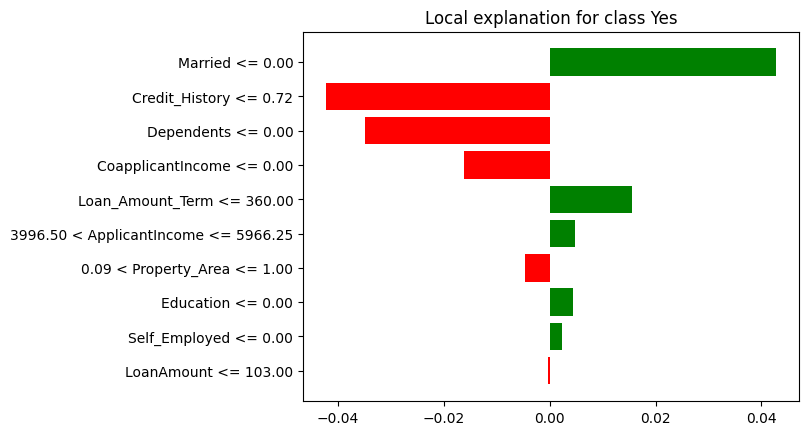

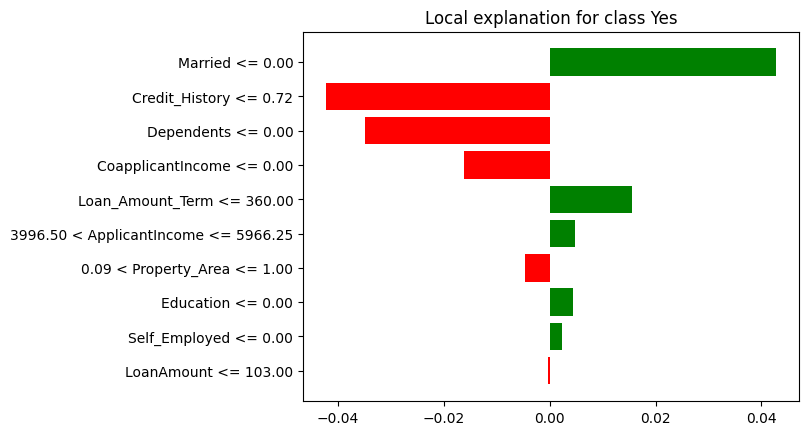

In [ ]:
explanation.as_pyplot_figure()

In [ ]:
#Choose an instance to explain
i = 6  # for example
instance = X_train_sm[i]

In [ ]:
explanation = explainer.explain_instance(
    data_row=instance,
    predict_fn=final_model.predict_proba,
    num_features=10
)
explanation.show_in_notebook()

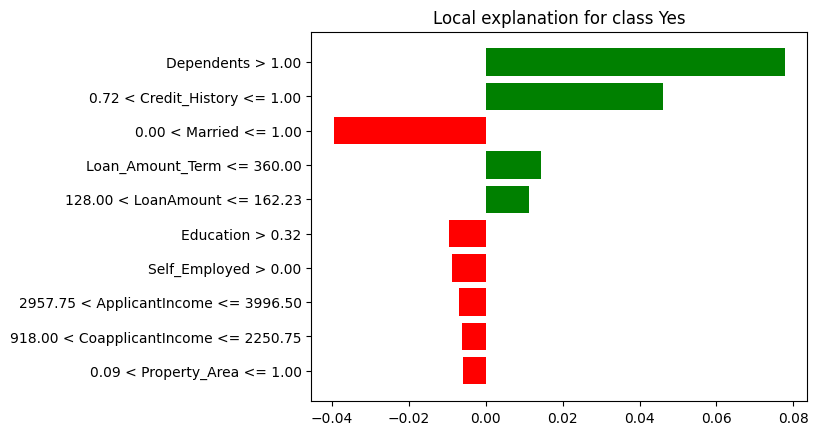

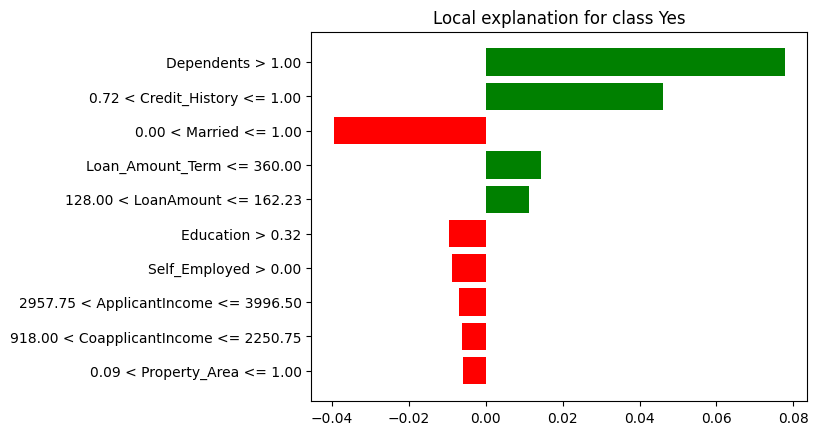

In [ ]:
explanation.as_pyplot_figure()